# Capstone Project: Movie Recommendation Engine

Advanced Data Scientist Program - IIT Roorkee (iHUB DivyaSampark) with Intellipaat

Dataset: Netflix Prize dataset (combined_data_1.txt, movie_titles.csv)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)


## Loading the ratings data

In [2]:
raw = pd.read_csv('combined_data_1.txt', header=None, names=['cust_id','rating'], usecols=[0,1])
raw['rating'] = raw['rating'].astype('float32')
raw.head()


,cust_id,rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [3]:
nan_mask = raw['rating'].isnull()
nan_idx = raw.index[nan_mask].to_numpy()
movie_id_vals = raw.loc[nan_mask, 'cust_id'].str.replace(':', '', regex=False).astype('int32').to_numpy()

bounds = np.append(nan_idx, len(raw))
counts = np.diff(bounds) - 1
movie_id_col = np.repeat(movie_id_vals, counts)

ratings = raw[~nan_mask].reset_index(drop=True)
ratings['movie_id'] = movie_id_col
ratings['cust_id'] = ratings['cust_id'].astype('int32')
ratings['rating'] = ratings['rating'].astype('int8')

ratings.shape


(24053764, 3)

In [4]:
ratings.head(10)


,cust_id,rating,movie_id
0,1488844,3,1
1,822109,5,1
2,885013,4,1
3,30878,4,1
4,823519,3,1
5,893988,3,1
6,124105,4,1
7,1248029,3,1
8,1842128,4,1
9,2238063,3,1


In [5]:
ratings['rating'].value_counts().sort_index()


rating
1    1118186
2    2439073
3    6904181
4    8085741
5    5506583
Name: count, dtype: int64

## Loading movie titles

In [6]:
titles = []
with open('movie_titles.csv', encoding='latin-1') as f:
    for line in f:
        parts = line.strip().split(',', 2)
        if len(parts) == 3:
            titles.append(parts)

movies = pd.DataFrame(titles, columns=['movie_id','year','title'])
movies['movie_id'] = movies['movie_id'].astype('int32')
movies.head()


,movie_id,year,title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


## Note on genre

The original coursework brief referenced a `Genre` field, but the actual Netflix Prize export
(`combined_data_1.txt` + `movie_titles.csv`) only carries `movie_id`, `customer_id`, `rating`, `year` and
`title` — there is no genre column in the source data. The objectives below are answered at the movie/title
level instead of genre level, since that's what the real dataset supports.


## Objective 1: Most popular and highest rated movies

In [7]:
movie_stats = ratings.groupby('movie_id').agg(num_ratings=('rating','count'), avg_rating=('rating','mean'))
movie_stats = movie_stats.merge(movies[['movie_id','title','year']], on='movie_id')
movie_stats = movie_stats.set_index('movie_id')
movie_stats.head()


,num_ratings,avg_rating,title,year
movie_id,,,,
1,547,3.749543,Dinosaur Planet,2003
2,145,3.558621,Isle of Man TT 2004 Review,2004
3,2012,3.641153,Character,1997
4,142,2.739437,Paula Abdul's Get Up & Dance,1994
5,1140,3.919298,The Rise and Fall of ECW,2004


In [8]:
most_popular = movie_stats.sort_values('num_ratings', ascending=False).head(15)
most_popular[['title','year','num_ratings','avg_rating']]


,title,year,num_ratings,avg_rating
movie_id,,,,
1905,Pirates of the Caribbean: The Curse of the Bla...,2003,193941,4.153908
2152,What Women Want,2000,162597,3.425322
3860,Bruce Almighty,2003,160454,3.434517
4432,The Italian Job,2003,156183,3.755364
571,American Beauty,1999,154832,3.962585
3938,Shrek 2,2004,153996,4.144543
4306,The Sixth Sense,1999,151292,4.325245
2452,Lord of the Rings: The Fellowship of the Ring,2001,149866,4.434708
1962,50 First Dates,2004,145519,3.750569


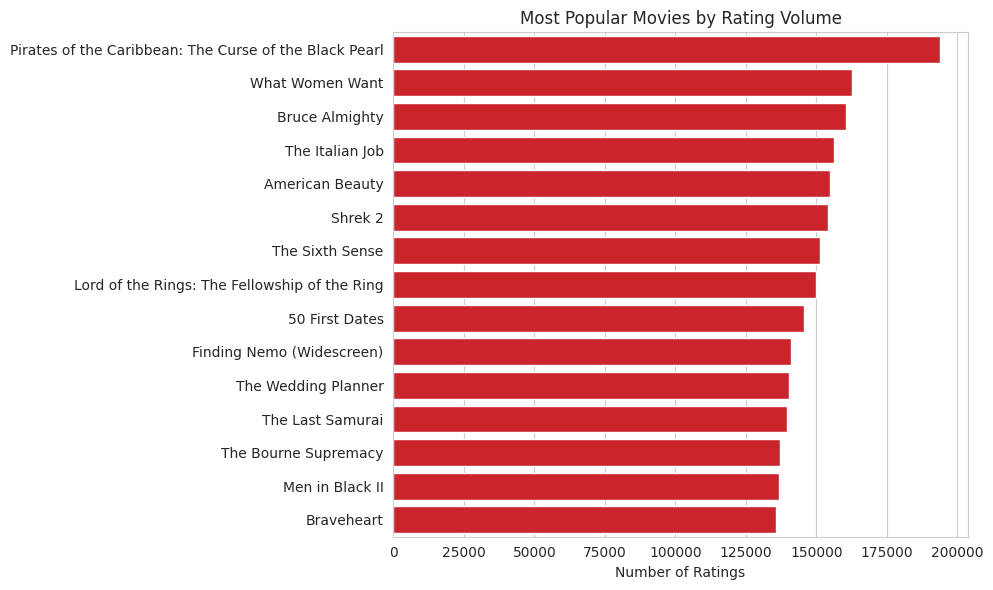

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(y=most_popular['title'], x=most_popular['num_ratings'], color='#E50914')
plt.xlabel('Number of Ratings')
plt.ylabel('')
plt.title('Most Popular Movies by Rating Volume')
plt.tight_layout()
plt.savefig('most_popular_movies.png', dpi=150)
plt.show()


In [10]:
benchmark = movie_stats['num_ratings'].quantile(0.7)
qualified = movie_stats[movie_stats['num_ratings'] >= benchmark]
highest_rated = qualified.sort_values('avg_rating', ascending=False).head(15)
highest_rated[['title','year','num_ratings','avg_rating']]


,title,year,num_ratings,avg_rating
movie_id,,,,
3456,Lost: Season 1,2004,7249,4.670989
2102,The Simpsons: Season 6,1994,8426,4.581296
4238,Inu-Yasha,2000,1883,4.554434
3444,Family Guy: Freakin' Sweet Collection,2004,10027,4.516007
4427,The West Wing: Season 3,2001,6633,4.473692
1476,Six Feet Under: Season 4,2004,11829,4.469693
2019,Samurai Champloo,2004,2000,4.467500
2568,Stargate SG-1: Season 8,2004,1812,4.461921
1947,Gilmore Girls: Season 3,2002,4829,4.448333


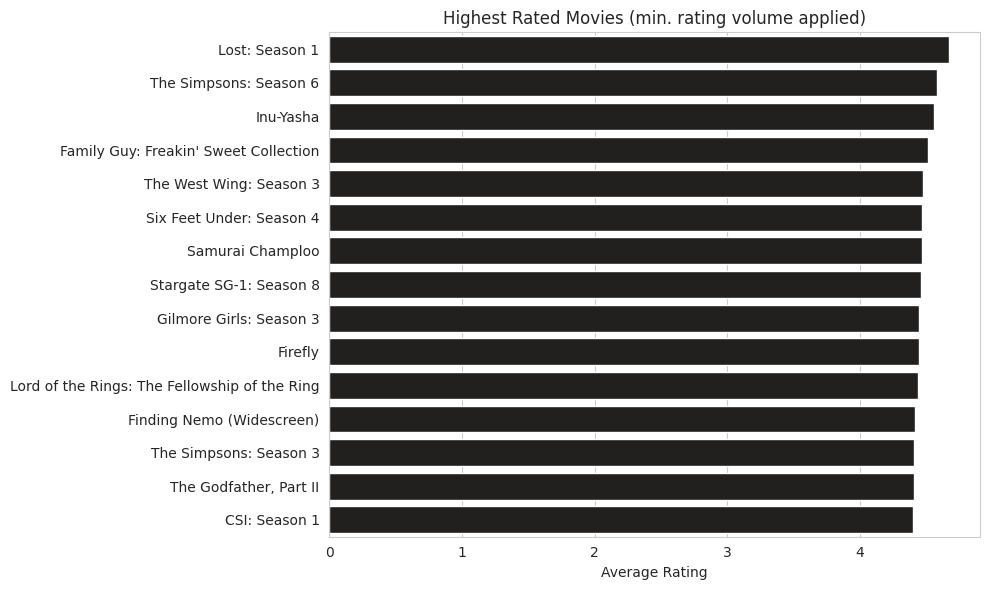

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(y=highest_rated['title'], x=highest_rated['avg_rating'], color='#221f1f')
plt.xlabel('Average Rating')
plt.ylabel('')
plt.title('Highest Rated Movies (min. rating volume applied)')
plt.tight_layout()
plt.savefig('highest_rated_movies.png', dpi=150)
plt.show()


## Objective 3: Best and worst rated movies

In [12]:
worst_rated = qualified.sort_values('avg_rating', ascending=True).head(15)
worst_rated[['title','year','num_ratings','avg_rating']]


,title,year,num_ratings,avg_rating
movie_id,,,,
3021,House of the Dead,2003,5589,1.962784
2276,Spice World,1998,1999,2.158579
4255,Gerry,2002,3861,2.200466
749,Ernest Goes to Jail,1990,3305,2.235401
3505,Freddy Got Fingered,2001,4812,2.252494
1100,Dr. T & the Women,2000,6084,2.254109
3567,Starship Troopers 2: Hero of the Federation,2004,4932,2.264801
3573,Cop and a Half,1993,5652,2.314933
289,The Avengers,1998,4412,2.334769


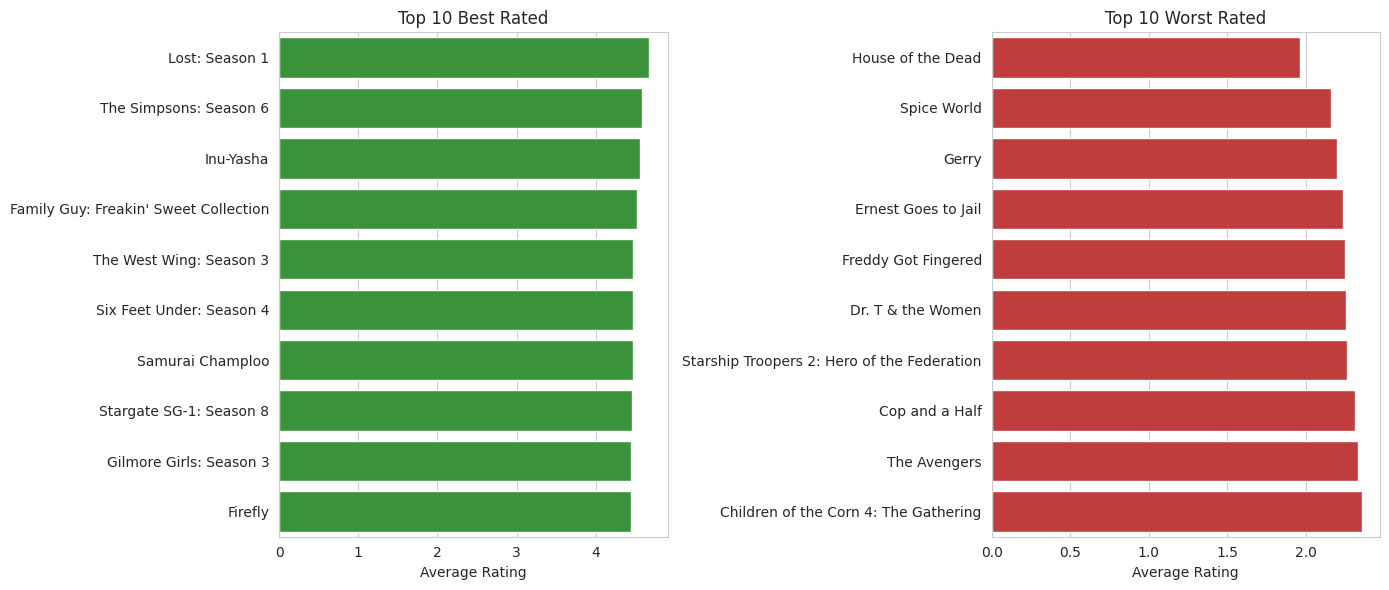

In [13]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
sns.barplot(y=highest_rated['title'].head(10), x=highest_rated['avg_rating'].head(10), ax=axes[0], color='#2ca02c')
axes[0].set_title('Top 10 Best Rated')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('')

sns.barplot(y=worst_rated['title'].head(10), x=worst_rated['avg_rating'].head(10), ax=axes[1], color='#d62728')
axes[1].set_title('Top 10 Worst Rated')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('best_worst_movies.png', dpi=150)
plt.show()


## Objective 2: Recommendation model

The full matrix (4,499 movies x 470,758 customers) is too sparse and too large to work with directly
on a single machine, so the dataset is trimmed to movies and customers with enough ratings to produce
reliable correlations, following the standard benchmark-quantile approach used for this dataset.


In [14]:
movie_rating_count = ratings.groupby('movie_id')['rating'].count()
cust_rating_count = ratings.groupby('cust_id')['rating'].count()

movie_benchmark = movie_rating_count.quantile(0.95)
cust_benchmark = cust_rating_count.quantile(0.95)

drop_movies = movie_rating_count[movie_rating_count < movie_benchmark].index
drop_custs = cust_rating_count[cust_rating_count < cust_benchmark].index

trimmed = ratings[~ratings['movie_id'].isin(drop_movies) & ~ratings['cust_id'].isin(drop_custs)]
trimmed.shape


(2941349, 3)

In [15]:
pivot = trimmed.pivot_table(index='cust_id', columns='movie_id', values='rating')
pivot.shape


(23620, 225)

In [16]:
corr_matrix = pivot.corr(min_periods=50)
corr_matrix.shape


(225, 225)

In [17]:
def similar_movies(movie_id, min_count=50):
    corr = corr_matrix[movie_id].dropna()
    corr = pd.DataFrame(corr)
    corr.columns = ['correlation']
    corr = corr.join(movie_stats['num_ratings'])
    corr = corr[corr['num_ratings'] >= min_count]
    corr = corr.join(movies.set_index('movie_id')['title'])
    return corr.sort_values('correlation', ascending=False)


In [18]:
sample_movie_id = corr_matrix.columns[0]
print(movies.set_index('movie_id').loc[sample_movie_id, 'title'])
similar_movies(sample_movie_id).head(10)


Lilo and Stitch


,correlation,num_ratings,title
movie_id,,,
28,1.000000,39752,Lilo and Stitch
2171,0.385250,33708,Brother Bear (Theatrical Widescreen Version)
2690,0.378780,28955,The Emperor's New Groove
3079,0.331708,67575,The Lion King: Special Edition
2290,0.319039,51856,Aladdin: Platinum Edition
1289,0.314653,32832,Look Who's Talking Too
1962,0.309745,145519,50 First Dates
2457,0.306612,34898,A Cinderella Story
334,0.305642,39875,The Pacifier


In [19]:
def recommend_for_customer(cust_id, top_n=5):
    if cust_id not in pivot.index:
        return highest_rated[['title','avg_rating']].head(top_n)

    customer_ratings = pivot.loc[cust_id].dropna().sort_values(ascending=False)
    if len(customer_ratings) == 0:
        return highest_rated[['title','avg_rating']].head(top_n)

    seed_movie = customer_ratings.index[0]
    candidates = similar_movies(seed_movie)
    already_rated = customer_ratings.index
    candidates = candidates[~candidates.index.isin(already_rated)]
    return candidates[['title','correlation']].head(top_n)


In [20]:
sample_customers = trimmed['cust_id'].drop_duplicates().sample(3, random_state=7)
for cid in sample_customers:
    print(f'Customer {cid}')
    print(recommend_for_customer(cid))
    print()


Customer 514787
                           title  correlation
movie_id                                     
1289      Look Who's Talking Too     0.360723
1267              Dr. Dolittle 2     0.339011
2391            Along Came Polly     0.315084
4341           The Scorpion King     0.276594
197                 Taking Lives     0.270587

Customer 2081120
                   title  correlation
movie_id                             
3917        Garden State     0.317978
788               Clerks     0.287284
413       Igby Goes Down     0.278910
1700       Bottle Rocket     0.263053
3626           25th Hour     0.255712

Customer 223890
                                        title  correlation
movie_id                                                  
4488                              Wonder Boys     0.324370
2465                       This Is Spinal Tap     0.275192
1700                            Bottle Rocket     0.263053
2922                                 Heathers     0.257890
2178   

In [21]:
all_recs = []
for cid in pivot.index:
    recs = recommend_for_customer(cid, top_n=3)
    for title in recs['title'].values:
        all_recs.append({'cust_id': cid, 'recommended_movie': title})

recommendations = pd.DataFrame(all_recs)
recommendations.to_csv('customer_recommendations.csv', index=False)
recommendations.shape


(70854, 2)

In [22]:
recommendations.head(10)


,cust_id,recommended_movie
0,7,Taking Lives
1,7,Coach Carter
2,7,Secondhand Lions
3,79,Sex and the City: Season 4
4,79,Elizabeth
5,79,10 Things I Hate About You
6,769,Bottle Rocket
7,769,Seven Samurai
8,769,Training Day
9,1310,Being John Malkovich


## Conclusion

Most popular titles by rating volume and highest/lowest rated titles (subject to a minimum rating-volume
benchmark) were identified from the full ratings dataset. A benchmark-quantile filter was applied to bring
the customer x movie matrix down to a workable size, after which an item-based collaborative filtering
approach (Pearson correlation between movie rating vectors) was used to generate personalised
recommendations for each customer, falling back to the overall highest-rated titles for customers outside
the trimmed matrix.

This is a correlation-based collaborative filtering approach rather than a full matrix factorization model.
A natural extension would be to run this on all four `combined_data_*.txt` files instead of just one, and to
compare against a matrix factorization baseline (e.g. `TruncatedSVD` or `surprise`'s SVD) using RMSE on a
held-out test split.
